## **| 비지도 학습 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch09 앙상블 학습과 랜덤 포레스트 연습문제 3, 5, 8, 10번
- 이론적 지식을 묻는 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

In [1]:
# import libraries
import numpy as np

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

### **1. k-평균을 사용할 때 적절한 클러스터 개수를 선택할 수 있는 두 가지 기법을 설명하세요.**
___



1. 엘보우 기법: k 값을 1부터 증가시키면서 각 k에 대한 클러스터 내 제곱합을 계산. k 값에 따라 Inertia가 급격히 감소하는 지점 찾기.

2. 실루엣 점수: 클러스터 내의 응집도와 클러스터 간의 분리도를 모두 측정하는 방법.
-1과 1 사이의 값으로 나타냄.
1: 샘플이 자신의 클러스터에 매우 가깝고. 다른 클러스터와는 멀리 떨어져 있음.
0: 샘플이 두 클러스터의 경계에 있음
-1: 샘플이 잘못된 클러스터에 할당되었음을 의미.

### **2. 대규모 데이터셋으로 확장할 수 있는 군집 알고리즘 두 개를 말해보세요. 밀도가 높은 지역을 찾는 군집 알고리즘 두 개는 무엇인가요?**
___


1. 대규모 데이터셋으로 확장할 수 있는 군집 알고리즘
- Mini-Batch K-Means
- BIRCH
2. 밀도가 높은 지역을 찾는 군집 알고리즘
- DBSCAN
- OPTICS


### **3. 가우시안 혼합이 무엇인가요? 어떤 작업에 사용할 수 있나요?**
___


가우시안 혼합(Gaussian Mixture)은 여러 개의 가우시안(정규) 분포가 혼합되어 데이터가 생성되었다고 가정하는 확률 모델이다. 각 데이터가 어떤 가우시안 분포에 속할 확률을 계산하여 군집을 구분한다. 주로 군집화, 밀도 추정, 이상치 탐지 등의 작업에 사용할 수 있다.

### **4. 다음 단계를 따라 올리베티 얼굴 데이터셋을 군집해보자..**
___
전통적인 올리베티 얼굴 데이터셋은 64 X 64 픽셀 크기의 흑백 얼굴 이미지 400개를 가지고 있습니다. 사람 40명의 사진을 10장씩 찍은 것인데, 각 이미지는 4096 크기의 1D 벡터로 펼쳐져 있습니다.

#### **STEP 1. 아래 코드를 실행하여 데이터셋을 불러오세요.**

In [2]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


####  **STEP 2. 데이터셋을 훈련 세트, 검증 세트, 테스트 세트로 나누세요.**
해당 데이터셋은 매우 작으므로, `StratifiedShuffleSplit` 함수를 이용하여, 계층적 샘플링으로 각 세트에 동일한 사람의 얼굴이 고루 섞이도록 하세요.

In [3]:
from sklearn.model_selection import StratifiedShuffleSplit

X = olivetti.data
y = olivetti.target

# train 60, 나머지 40
split = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)

for train_idx, temp_idx in split.split(X, y):
    X_train = X[train_idx]
    y_train = y[train_idx]

    X_temp = X[temp_idx]
    y_temp = y[temp_idx]


# 남은 데이터를 validation 20%, test 20%로 분할
split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)

for val_idx, test_idx in split2.split(X_temp, y_temp):
    X_val = X_temp[val_idx]
    y_val = y_temp[val_idx]

    X_test = X_temp[test_idx]
    y_test = y_temp[test_idx]

####  **STEP 3. 속도를 높이기 위해 각 학습/검증/테스트 피처 데이터셋에 PCA을 적용하여 데이터의 차원을 줄이세요.**
- `n_componets = 0.99`로 설정합니다.

In [4]:
from sklearn.decomposition import PCA

pca = PCA(0.99)

X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

####  **STEP 4. 교재에서 다룬 방법을 사용하여 적절한 클러스터 개수를 찾고 k-평균을 사용해 이미지를 군집해보세요.**

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

candidate_k=range(5,200,10)
models={k:KMeans(n_clusters=k,random_state=42).fit(X_train_pca) for k in candidate_k}
scores={k:silhouette_score(X_train_pca,models[k].labels_) for k in candidate_k}

best_k=max(scores,key=scores.get)
best_score=scores[best_k]

best_k, best_score

(105, np.float32(0.20625582))

In [12]:
best_model=models[best_k]
cluster_labels=best_model.labels_
cluster_labels

array([ 34,  27,  15,  34,   1,  59,  63,  17,  34,  25,  25,  59,  86,
        55,   1,  33,  28,  41,  37,  12,  70,  80,  87,   3,  69,  88,
        21,  75,  28,  31,   7,  59,  98,  93,  10,  46,  26,  96,  20,
        19,  13,  53,  65,   3,  83, 100,   3,  87,  44,  78,  94,  80,
        91,  15,  28,   5,  18,  44,  49,  26,  22,  65,  52,  23,  54,
        30, 103,  71,  48,  45,   5,  42,  63,  61,  68,  11,  10,  13,
        45,  28,  16,   4,  23,  49,  53,  72,  99,  74,  20,   0,  61,
        60,  80, 102,  59,  38,  18,  30, 104,  50,  30,  58,  67,  76,
        87,  90,  70,  40,  38,  97,  15,  17,  57,  39, 101,  23,   2,
        50,  92,  95,   6,  75,  16,  43,  40,   8,  11,  71,  57,  20,
        32,  43,  35,  68,   1,   8,  36,  19,   4,  85,  49,  55,  82,
         5,   2,   8,   1,  42,   1,  19,   4,  29,  51,  77,  27,  33,
        27,  35,  14,  36,  15,   6,  81,  54,   4,  29,  52,  90,  26,
        42,  64,  24,  64,  13,  75,  40,  79,  72,  56,  89,  1

####  **STEP 5. 아래 `plot_faces` 함수를 이용하여, 클러스터를 시각화하고, 각 클러스터에 비슷한 얼굴이 들어있는지 확인해보세요.**

In [9]:
# plot_faces 함수
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

클러스터 0


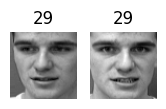

클러스터 1


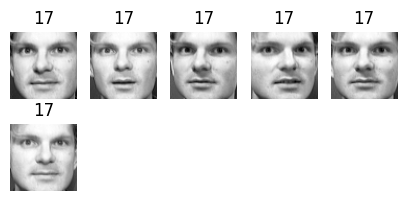

클러스터 2


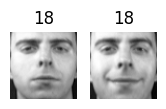

클러스터 3


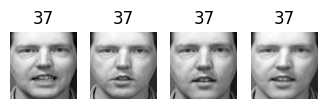

클러스터 4


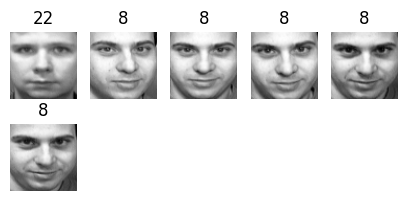

클러스터 5


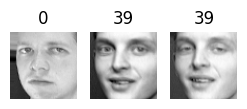

클러스터 6


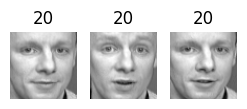

클러스터 7


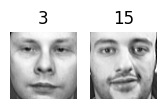

클러스터 8


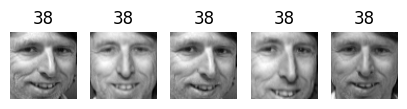

클러스터 9


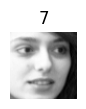

클러스터 10


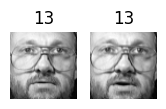

클러스터 11


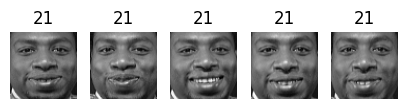

클러스터 12


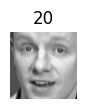

클러스터 13


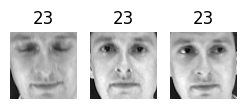

클러스터 14


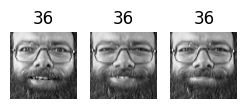

클러스터 15


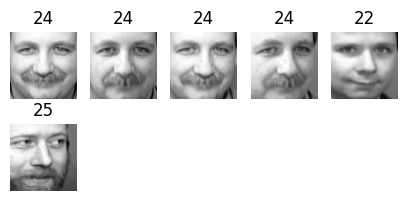

클러스터 16


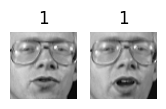

클러스터 17


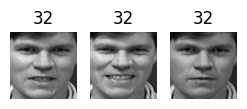

클러스터 18


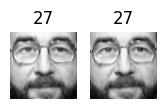

클러스터 19


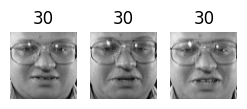

클러스터 20


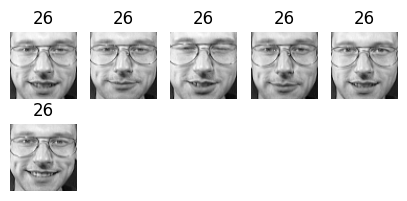

클러스터 21


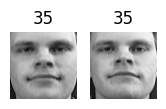

클러스터 22


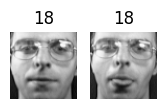

클러스터 23


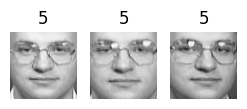

클러스터 24


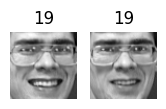

클러스터 25


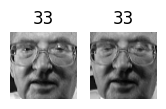

클러스터 26


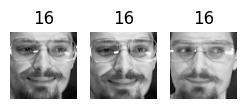

클러스터 27


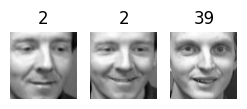

클러스터 28


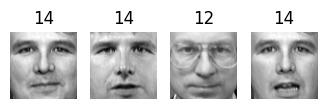

클러스터 29


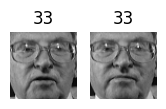

클러스터 30


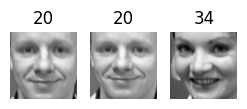

클러스터 31


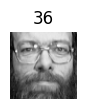

클러스터 32


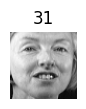

클러스터 33


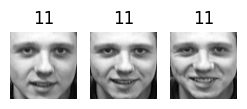

클러스터 34


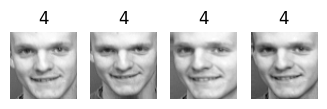

클러스터 35


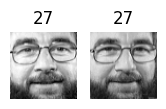

클러스터 36


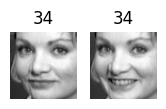

클러스터 37


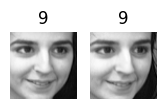

클러스터 38


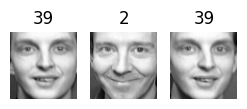

클러스터 39


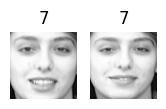

클러스터 40


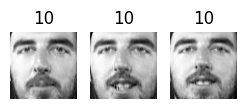

클러스터 41


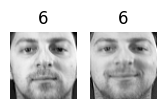

클러스터 42


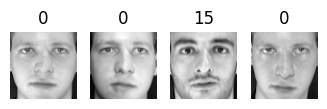

클러스터 43


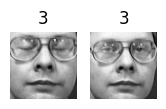

클러스터 44


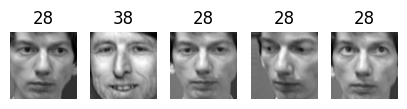

클러스터 45


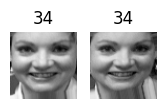

클러스터 46


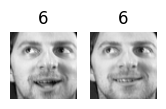

클러스터 47


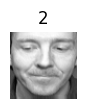

클러스터 48


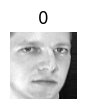

클러스터 49


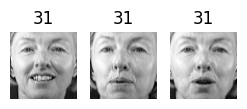

클러스터 50


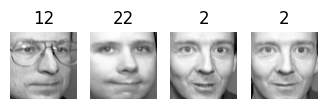

클러스터 51


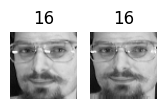

클러스터 52


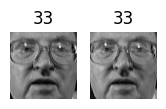

클러스터 53


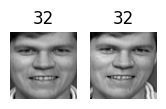

클러스터 54


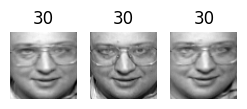

클러스터 55


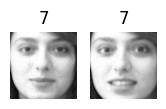

클러스터 56


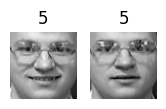

클러스터 57


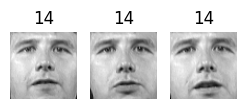

클러스터 58


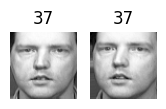

클러스터 59


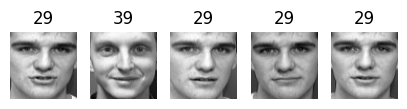

클러스터 60


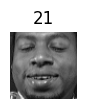

클러스터 61


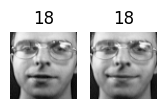

클러스터 62


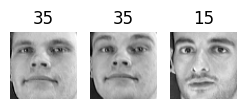

클러스터 63


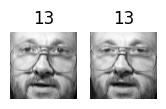

클러스터 64


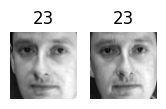

클러스터 65


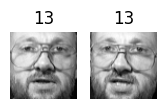

클러스터 66


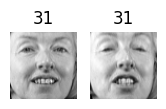

클러스터 67


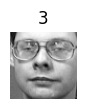

클러스터 68


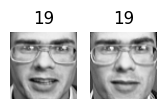

클러스터 69


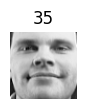

클러스터 70


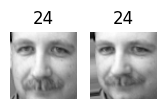

클러스터 71


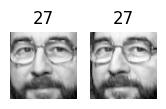

클러스터 72


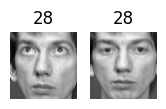

클러스터 73


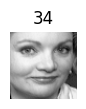

클러스터 74


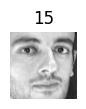

클러스터 75


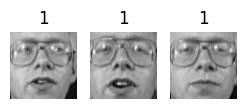

클러스터 76


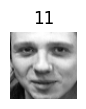

클러스터 77


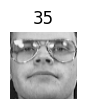

클러스터 78


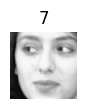

클러스터 79


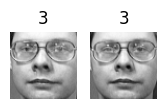

클러스터 80


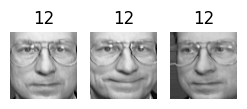

클러스터 81


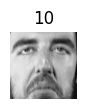

클러스터 82


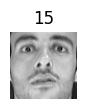

클러스터 83


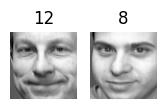

클러스터 84


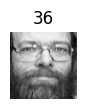

클러스터 85


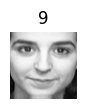

클러스터 86


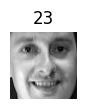

클러스터 87


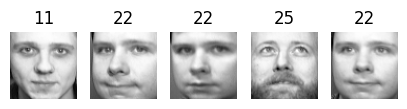

클러스터 88


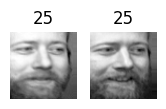

클러스터 89


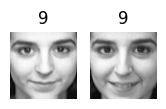

클러스터 90


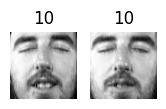

클러스터 91


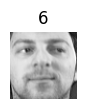

클러스터 92


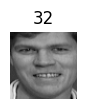

클러스터 93


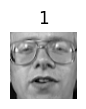

클러스터 94


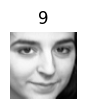

클러스터 95


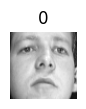

클러스터 96


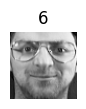

클러스터 97


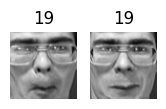

클러스터 98


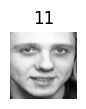

클러스터 99


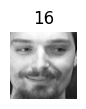

클러스터 100


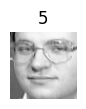

클러스터 101


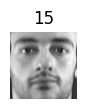

클러스터 102


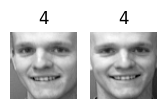

클러스터 103


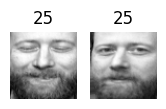

클러스터 104


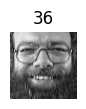

In [13]:
for cluster_id in np.unique(cluster_labels):
  print(f"클러스터 {cluster_id}")
  in_cluster = (cluster_labels == cluster_id)
  faces = X_train[in_cluster]
  labels = y_train[in_cluster]
  plot_faces(faces, labels)